# Download dataset :

In [ ]:
!pip install boto3

In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.client import Config

# Define client :
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

_________

## Train set :

The dataset contains images at different resolutions and formats, including multispectral, panchromatic, and pan-sharpened RGB images, as well as pre-tiled 512×512 PNG images ready for ML, with corresponding GeoJSON annotations.

**Images (different resolutions and formats)**

- **MS** – 16-bit, 8-channel multispectral (.tif), lower spatial resolution.  
- **PAN** – 16-bit panchromatic (.tif), black & white, high resolution.  
- **PS-RGB** – 8-bit pan-sharpened RGB (.tif), true color, high resolution.  
- **PS-RGB_cog** – 8-bit pan-sharpened RGB (.tif), optimized for cloud streaming.  
- **PS-RGB_tiled** – 512×512 tiles in PNG, each tile contains ≥1 aircraft, ML-ready.  

**Labels / Annotations**

- **geojson_aircraft** – GeoJSON annotations for full images.  
- **geojson_aircraft_tiled** – GeoJSON / COCO annotations for each 512×512 tile.  


For our CNN-based aircraft detection experiments, we will use the **PS-RGB_tiled** images (512×512 PNG tiles, each containing at least one aircraft, ready for object detection, ~2 GB for the training set) along with the corresponding **geojson_aircraft_tiled** labels, which provide bounding boxes aligned to each tile and can be directly parsed for PyTorch or TensorFlow training.


In [ ]:
resp = s3.list_objects_v2(
    Bucket="rareplanes-public",
    Prefix="real/tarballs/train"
)

for obj in resp["Contents"][:]:
    print(obj["Key"], obj["Size"] / 1e6, "MB")

real/tarballs/train/RarePlanes_train_MS.tar.gz 12661.954634 MB
real/tarballs/train/RarePlanes_train_PAN.tar.gz 23495.266418 MB
real/tarballs/train/RarePlanes_train_PS-RGB.tar.gz 31436.323331 MB
real/tarballs/train/RarePlanes_train_PS-RGB_cog.tar.gz 2402.034321 MB
real/tarballs/train/RarePlanes_train_PS-RGB_tiled.tar.gz 2039.032455 MB
real/tarballs/train/RarePlanes_train_geojson_aircraft.tar.gz 1.293252 MB
real/tarballs/train/RarePlanes_train_geojson_aircraft_tiled.tar.gz 2.941328 MB


### Download Images : **PS-RGB_titled**

In [ ]:
# Install AWS CLI :
# Update package lists first
!apt-get update --fix-missing -qq

# Then install awscli
!apt-get install awscli -y -qq

In [ ]:
# Upgrade pip first (optional but recommended)
!pip install --upgrade pip --quiet

# Install AWS CLI
!pip install awscli --upgrade --quiet

# Verify installation
!aws --version

In [ ]:
# Create a working directory for train set :
!mkdir -p /content/rareplanes/train

# Download data :
!aws s3 cp \
s3://rareplanes-public/real/tarballs/train/RarePlanes_train_PS-RGB_tiled.tar.gz \
/content/rareplanes/train/ \
--no-sign-request

download: s3://rareplanes-public/real/tarballs/train/RarePlanes_train_PS-RGB_tiled.tar.gz to rareplanes/train/RarePlanes_train_PS-RGB_tiled.tar.gz


In [ ]:
# Extract :
!tar -xzvf /content/rareplanes/train/RarePlanes_train_PS-RGB_tiled.tar.gz \
-C /content/rareplanes/train/

### Download the labels : **geojson_aircraft_labels**

In [ ]:
# Download the data :
!aws s3 cp \
s3://rareplanes-public/real/tarballs/train/RarePlanes_train_geojson_aircraft_tiled.tar.gz \
/content/rareplanes/train/ \
--no-sign-request

download: s3://rareplanes-public/real/tarballs/train/RarePlanes_train_geojson_aircraft_tiled.tar.gz to rareplanes/train/RarePlanes_train_geojson_aircraft_tiled.tar.gz


In [ ]:
# Extract :
!tar -xzvf /content/rareplanes/train/RarePlanes_train_geojson_aircraft_tiled.tar.gz \
-C /content/rareplanes/train/

___________

# Test Data :

In [ ]:
# Explore test directory in S3 bucket :
resp = s3.list_objects_v2(
    Bucket="rareplanes-public",
    Prefix="real/tarballs/test"
)

for obj in resp["Contents"][:]:
    print(obj["Key"], obj["Size"] / 1e6, "MB")

real/tarballs/test/RarePlanes_test_MS.tar.gz 7582.510107 MB
real/tarballs/test/RarePlanes_test_PAN.tar.gz 14079.886527 MB
real/tarballs/test/RarePlanes_test_PS-RGB.tar.gz 18493.41576 MB
real/tarballs/test/RarePlanes_test_PS-RGB_cog.tar.gz 1372.1843 MB
real/tarballs/test/RarePlanes_test_PS-RGB_tiled.tar.gz 932.598104 MB
real/tarballs/test/RarePlanes_test_geojson_aircraft.tar.gz 0.456446 MB
real/tarballs/test/RarePlanes_test_geojson_aircraft_tiled.tar.gz 1.136277 MB


### Download Images : **PS-RGB_titled**



In [ ]:
# Create a working directory for train set :
!mkdir -p /content/rareplanes/test

# Download data :
!aws s3 cp \
s3://rareplanes-public/real/tarballs/test/RarePlanes_test_PS-RGB_tiled.tar.gz \
/content/rareplanes/test/ \
--no-sign-request

download: s3://rareplanes-public/real/tarballs/test/RarePlanes_test_PS-RGB_tiled.tar.gz to rareplanes/test/RarePlanes_test_PS-RGB_tiled.tar.gz


In [ ]:
# Extract :
!tar -xzvf /content/rareplanes/test/RarePlanes_test_PS-RGB_tiled.tar.gz \
-C /content/rareplanes/test/

### Download the labels : **geojson_aircraft_labels**

In [ ]:
# Download the data :
!aws s3 cp \
s3://rareplanes-public/real/tarballs/test/RarePlanes_test_geojson_aircraft_tiled.tar.gz \
/content/rareplanes/test/ \
--no-sign-request

download: s3://rareplanes-public/real/tarballs/test/RarePlanes_test_geojson_aircraft_tiled.tar.gz to rareplanes/test/RarePlanes_test_geojson_aircraft_tiled.tar.gz


In [ ]:
# Extract :
!tar -xzvf /content/rareplanes/test/RarePlanes_test_geojson_aircraft_tiled.tar.gz \
-C /content/rareplanes/test/

__________

# Data exploration :

| Type                 | Naming                       | Notes                                    |
| -------------------- | ---------------------------- | ---------------------------------------- |
| Images               | `sceneID_tileNumber.png`     | e.g., `96_104001000896F900_tile_916.png` |
| Tiled geojson labels | `sceneID_tileNumber.geojson` | Bounding boxes for that tile only        |
| Full geojson labels  | `sceneID.geojson`            | Bounding boxes for the **entire scene**  |


In [ ]:
# Data folder size :
!du -sh /content/rareplanes/

5.7G	/content/rareplanes/


In [ ]:
import os
import json
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import xml.dom.minidom

In [ ]:
train_img_dir = "/content/rareplanes/train/PS-RGB_tiled"
test_img_dir = "/content/rareplanes/test/PS-RGB_tiled"
train_labels_dir = "/content/rareplanes/train/geojson_aircraft_tiled"
test_labels_dir = "/content/rareplanes/test/geojson_aircraft_tiled"

## Inspect data :

### Labels :

In [ ]:
# List all files in the directory
files = os.listdir(train_labels_dir)

print("Total files in directory:", len(files))

print("\nFirst 5 files in the directory:")
for f in files[:5]:
    print(f)

first_file_path = os.path.join(train_labels_dir, files[2])
with open(first_file_path, "r") as f:
    content = f.read()

print("\n--- Content of the first file ---\n")
print(content)
print("\n--- End of file ---")

Total files in directory: 5815

First 5 files in the directory:
66_104001002227AF00_tile_87.geojson
4_10400100101BE000_tile_857.geojson
86_1040010049B46C00_tile_50.geojson
18_10400100211BDD00_tile_3854.geojson
130_104001002E47CD00_tile_1278.geojson

--- Content of the first file ---

{
"type": "FeatureCollection",
"crs": { "type": "name", "properties": { "name": "urn:ogc:def:crs:OGC:1.3:CRS84" } },
"features": [
{ "type": "Feature", "properties": { "loc_id": 86, "cat_id": "1040010049B46C00", "location": "Palm Beach International Airport, Arrivals, West Gate, Palm Beach County, Florida, 33406-1507, USA", "role": "Medium Civil Transport\/Utility", "role_id": 2, "is_plane": 1, "num_engines": 2, "propulsion": "jet", "canards": "no", "num_tail_fins": 1, "wing_position": "mid\/low mounted", "wing_type": "swept", "length": 27.678540552857115, "wingspan": 22.650911792239146, "area": 313.15421763534812, "faa_wingspan_class": 2, "Public_Train": 1, "Public_Test": 0, "partialDec": 0.58730019315791

### Images :

Each image has a **xml** file :

In [ ]:
# List all files in the directory
files = os.listdir(train_img_dir)

print("Total files in directory:", len(files))

print("\nFirst 5 files in the directory:")
for f in files[:5]:
    print(f)

first_file_path = os.path.join(train_img_dir, files[1])
with open(first_file_path, "r") as f:
    content = f.read()

print("\n--- Content of the first file ---\n")
print(content)
print("\n--- End of file ---")


Total files in directory: 11630

First 5 files in the directory:
96_104001000896F900_tile_916.png
97_104001003D4C1D00_tile_260.png.aux.xml
54_1040010024086400_tile_347.png
84_10400100460EF400_tile_278.png
127_1040010022BC3B00_tile_297.png.aux.xml

--- Content of the first file ---

<PAMDataset>
  <SRS>GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AUTHORITY["EPSG","4326"]]</SRS>
  <GeoTransform> -1.2192852882949327e+02,  2.9913898961180066e-06,  0.0000000000000000e+00,  3.7367306981682638e+01,  0.0000000000000000e+00, -2.9913898961180066e-06</GeoTransform>
  <Metadata>
    <MDI key="NODATA_VALUES">0 0 0</MDI>
  </Metadata>
  <Metadata domain="IMAGE_STRUCTURE">
    <MDI key="INTERLEAVE">PIXEL</MDI>
  </Metadata>
  <Metadata domain="RPC">
    <MDI key="HEIGHT_OFF">26</MDI>
    <MDI key="HEIGHT_SCALE">500</MDI>
    <MDI key="LAT_OFF">37.3313</MDI>
    <MDI 

### Number of img & labels :

In [ ]:
# List all files ending with .png
def get_images(dir):
  img_files = []
  for img in os.listdir(dir):
    if img.endswith(".png"):
      img_files.append(img)
  return img_files
# Count them
test_size = len(get_images(test_img_dir))
train_size = len(get_images(train_img_dir))

print(f"Number of images (train): {train_size}")
print(f"Number of images (test): {test_size}")

Number of images (train): 5815
Number of images (test): 2710


In [ ]:
# List all files ending with .png
def labels_shape(dir):
  labels = []
  for img in os.listdir(dir):
    labels.append(img)
  return labels

# Count them
test_size = len(labels_shape(test_labels_dir))
train_size = len(labels_shape(train_labels_dir))

print(f"Number of labels (train): {train_size}")
print(f"Number of labels (test): {test_size}")

Number of labels (train): 5815
Number of labels (test): 2710


### Display images & labels :

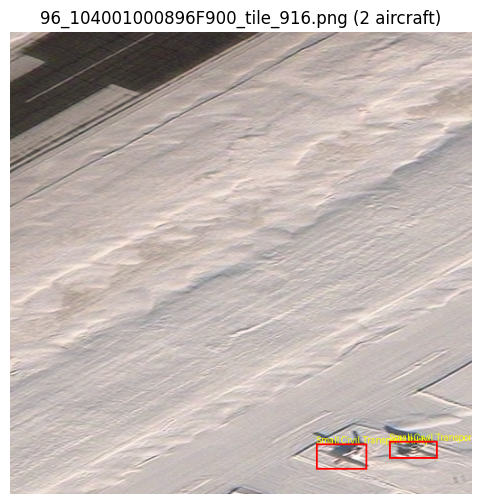

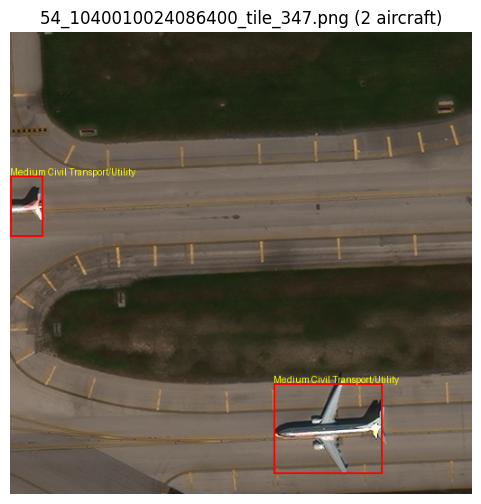

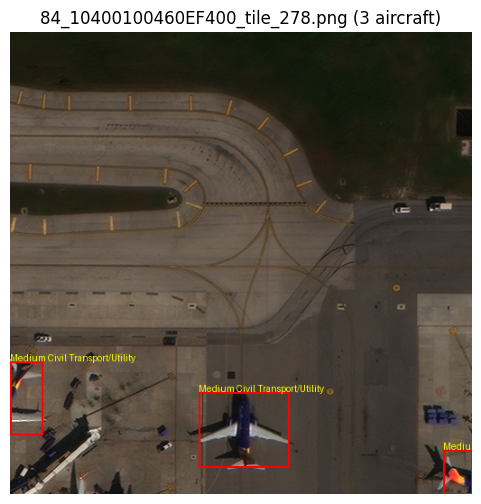

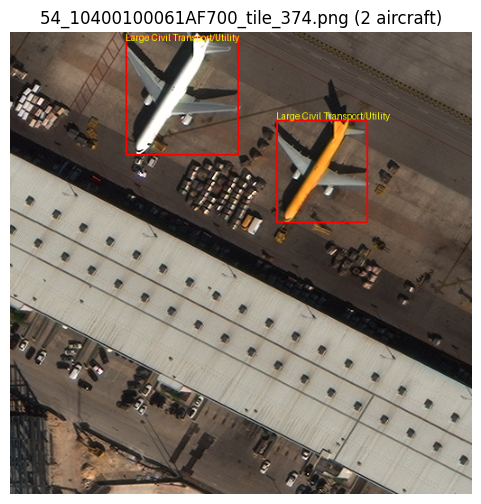

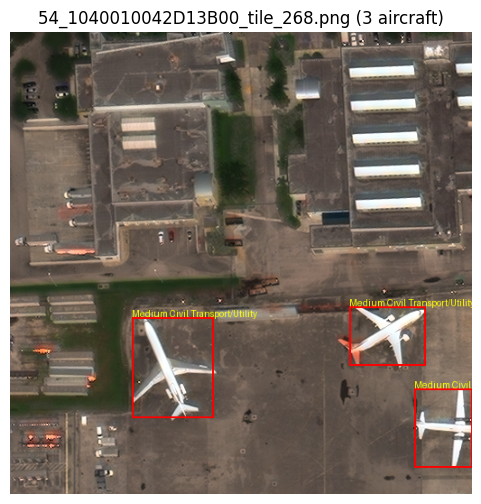

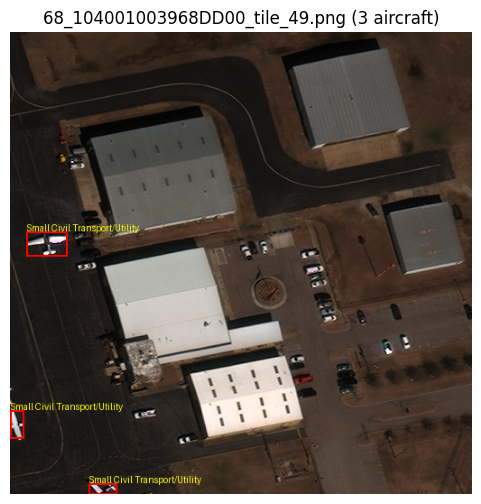

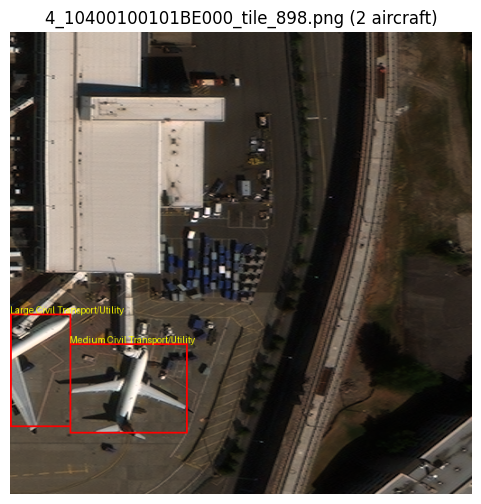

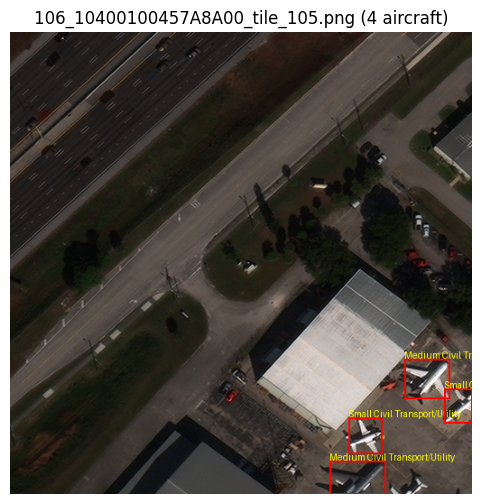

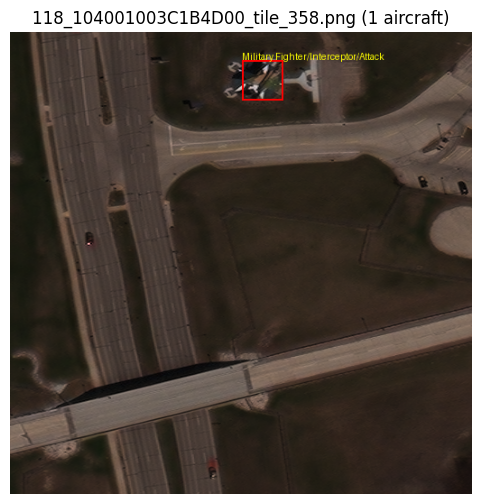

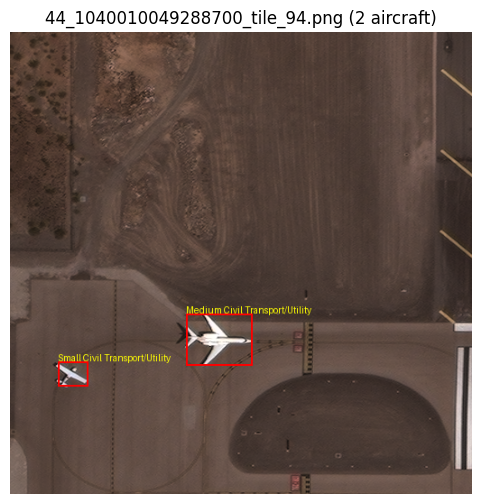

In [ ]:
import os
import json
import rasterio
from rasterio.plot import reshape_as_image
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def lonlat_to_pixel(transform, lon, lat):
    """
    Convert geographic coordinates (lon, lat) to image pixel coordinates (x, y)
    using the rasterio affine transform.
    """
    px, py = ~transform * (lon, lat)  # the ~ operator inverts the transform
    return int(px), int(py)


# Get image filenames
image_files = [f for f in os.listdir(train_img_dir) if f.endswith(".png")]

N = 10
for img_name in image_files[:N]:
    img_path = os.path.join(train_img_dir, img_name)
    base = os.path.splitext(img_name)[0]
    label_path = os.path.join(train_labels_dir, base + ".geojson")

    # Open image with rasterio to get georeferencing
    with rasterio.open(img_path) as src:
        img_array = src.read()  # (channels, H, W)
        img_array = reshape_as_image(img_array)  # convert to (H, W, C)
        transform = src.transform  # affine transform for lon/lat → pixel

    img = Image.fromarray(img_array)
    draw = ImageDraw.Draw(img)

    if os.path.exists(label_path):
        with open(label_path) as f:
            data = json.load(f)

        for feature in data['features']:
            coords = feature['geometry']['coordinates'][0]  # polygon corners
            pixel_coords = [lonlat_to_pixel(transform, lon, lat) for lon, lat in coords]

            x_coords = [p[0] for p in pixel_coords]
            y_coords = [p[1] for p in pixel_coords]
            x1, y1 = min(x_coords), min(y_coords)
            x2, y2 = max(x_coords), max(y_coords)

            # Draw bounding box
            draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

            # Draw aircraft type
            label = feature['properties']['role']
            draw.text((x1, max(y1-10,0)), label, fill="yellow")

    # Show the image
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f"{img_name} ({len(data['features'])} aircraft)")
    plt.axis('off')
    plt.show()
